In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print(df.head())
print("-" * 30)
price_analysis = df.groupby("InternetService")["MonthlyCharges"].mean()
print(price_analysis)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [26]:
from sklearn.model_selection import GridSearchCV, train_test_split
X= df.drop(columns=["Churn"])
y = df["Churn"].apply(lambda x: 1 if x=="Yes" else 0)
x_train, x_test, y_train, y_test = train_test_split(X, y, random_state= 42, test_size=0.2, stratify=y)


In [27]:
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
def churn_engineering_feature(X):
    x_copy = X.copy()
    x_copy["IsFiber"] = (x_copy["InternetService"]=="Fiber optic").astype(int)
    cat_col = ["PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
    x_copy["Total_Services"] = (x_copy[cat_col] == "Yes").sum(axis = 1)
    x_copy["TotalCharges"] = pd.to_numeric(x_copy["TotalCharges"], errors='coerce').fillna(0)
    x_copy["ChargesPerMonth"] = x_copy["TotalCharges"]/(x_copy["tenure"] +0.1)
    return x_copy.drop(columns=["gender", "customerID", "InternetService"])
new_features = FunctionTransformer(churn_engineering_feature)

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_recall_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

cat_col = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']
num_col = ["IsFiber", "Total_Services", "ChargesPerMonth", "SeniorCitizen", "tenure", "TotalCharges"]

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
cat_features = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
num_feature = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
preproces = ColumnTransformer([
    ("num", num_feature, num_col),
    ("cat", cat_features, cat_col)
])
pipe = Pipeline(steps=[
    ("new_feature", new_features),
    ("preproces", preproces),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
         scale_pos_weight= scale_pos_weight
        ))
])


In [29]:

param_grid = {
    'model__n_estimators':[100, 400],
    'model__max_depth': [3, 4, 5],
    'model__learning_rate':[0.01, 0.05, 0.1],
    'model__subsample': [0.8, .9],
    "model__colsample_bytree": [0.8, .9, 1.0],
}

grid = GridSearchCV(
    estimator= pipe,
    param_grid= param_grid,
    cv=5,
    scoring='recall',
    n_jobs= -1,
    verbose= 2
)

grid.fit(x_train, y_train)

print(f"Best Parameter of Model is:", grid.best_params_)
print(f"Best Validation Score is:", grid.best_score_)
best_model= grid.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameter of Model is: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 400, 'model__subsample': 0.9}
Best Validation Score is: 0.8127090301003344


Error Analysis

Confusion Matrix and classification report

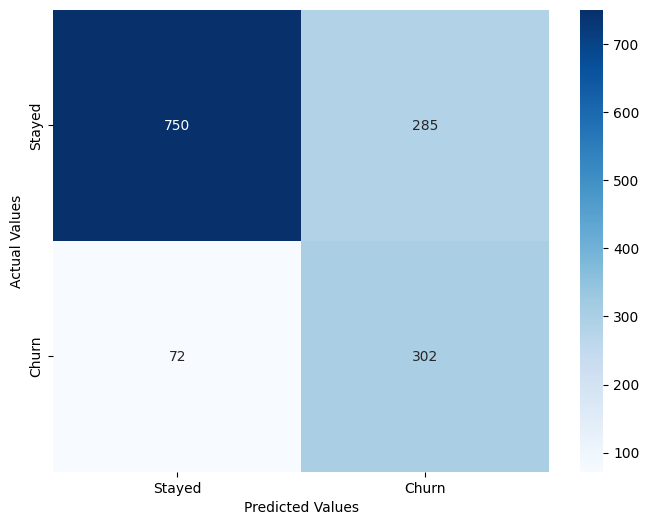

              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1035
           1       0.51      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



In [30]:
y_pred = best_model.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot= True, fmt="d", cmap="Blues",
            xticklabels=["Stayed", "Churn"],
            yticklabels=["Stayed", "Churn"])
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.tight_layout
plt.show()
print(classification_report(y_test, y_pred))

Probability distribution

In [31]:
y_prob = best_model.predict_proba(x_test)[:, 1]
errordf = x_test.copy()
errordf["y_true"] = y_test.values
errordf["y_pred"] = y_pred
errordf["y_prob"] = y_prob

false_negative = errordf[(errordf["y_true"]==1)&(errordf["y_pred"]==0)]
false_positive = errordf[(errordf["y_true"]==0)&(errordf["y_pred"]==1)]
true_negative = errordf[(errordf["y_true"]==0)&(errordf["y_pred"]==0)]
true_positive = errordf[(errordf["y_true"]==1)&(errordf["y_pred"]==1)]

print(false_negative["y_prob"].describe())
print("--" * 30)
print(false_positive["y_prob"].describe())
print("--" * 30)
print(true_positive["y_prob"].describe())
print(true_negative["y_prob"].describe())

count    72.000000
mean      0.324149
std       0.113266
min       0.041179
25%       0.264727
50%       0.348888
75%       0.404576
max       0.492403
Name: y_prob, dtype: float64
------------------------------------------------------------
count    285.000000
mean       0.670976
std        0.108465
min        0.500777
25%        0.573292
50%        0.655527
75%        0.747195
max        0.903812
Name: y_prob, dtype: float64
------------------------------------------------------------
count    302.000000
mean       0.752179
std        0.113161
min        0.509787
25%        0.666789
50%        0.770261
75%        0.848022
max        0.929823
Name: y_prob, dtype: float64
count    750.000000
mean       0.191702
std        0.139246
min        0.029750
25%        0.071364
50%        0.139516
75%        0.300660
max        0.499672
Name: y_prob, dtype: float64


In [32]:
threshold_to_test = [0.50, 0.45,0.40, 0.35, 0.30]
results =[]
for t in threshold_to_test:
    y_prob_t = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_prob_t).ravel()
    results.append({
        "Threshold" : t,
        "FN" : fn,
        "FP" : fp,
        "TP" : tp,
        "TN" : tn 
    })

pd.DataFrame(results)

,Threshold,FN,FP,TP,TN
0,0.50,72,285,302,750
1,0.45,65,331,309,704
2,0.40,51,363,323,672
3,0.35,37,424,337,611
4,0.30,25,474,349,561


In [33]:
from sklearn.metrics import precision_recall_curve, average_precision_score
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)
print("Average Precision (PR-AUC):", ap_score)

Average Precision (PR-AUC): 0.6610130307053733


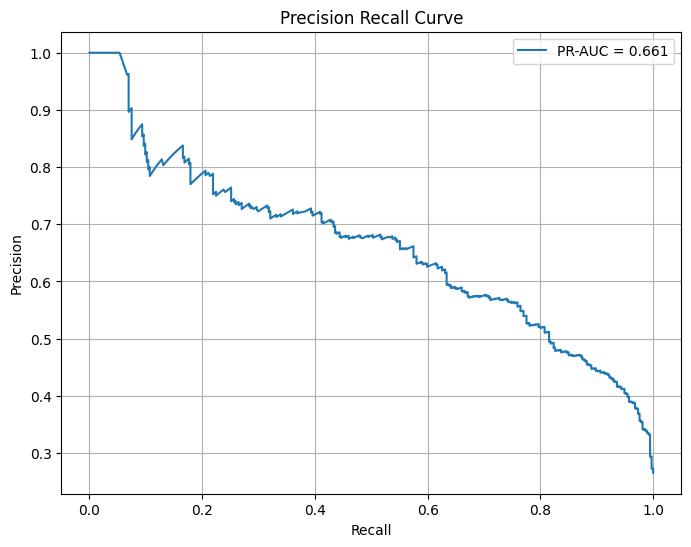

In [34]:
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f"PR-AUC = {ap_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
import pandas as pd

threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

threshold_df.head()


,threshold,precision,recall
0,0.029750,0.265436,1.0
1,0.029943,0.265625,1.0
2,0.030049,0.266003,1.0
3,0.030220,0.266572,1.0
4,0.030259,0.266762,1.0


Calibration of Model

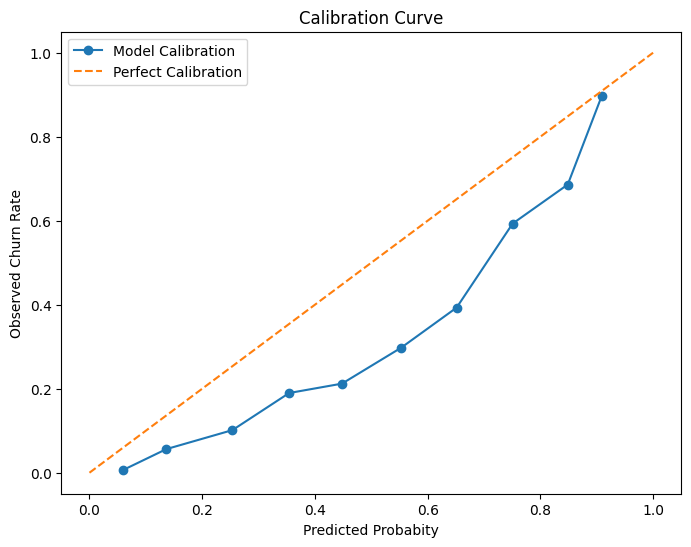

In [36]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

prob_True, prob_pred = calibration_curve(y_test, y_prob, n_bins= 10, strategy="uniform")

plt.figure(figsize=(8,6))
plt.plot(prob_pred, prob_True, marker= "o", label="Model Calibration")
plt.plot([0, 1], [0,1], linestyle='--', label="Perfect Calibration")
plt.xlabel("Predicted Probabity")
plt.ylabel("Observed Churn Rate")
plt.legend()
plt.title("Calibration Curve")
plt.show()

In [37]:
from sklearn.metrics import brier_score_loss
brier_score = brier_score_loss(y_test, y_prob)
print(brier_score)

0.1631908453528585


In [38]:
calibrated_model = CalibratedClassifierCV(
    estimator= best_model,
    method= "sigmoid",
    cv= 5
)

calibrated_model.fit(x_train, y_train)
cal_prob = calibrated_model.predict_proba(x_test)[:,1]




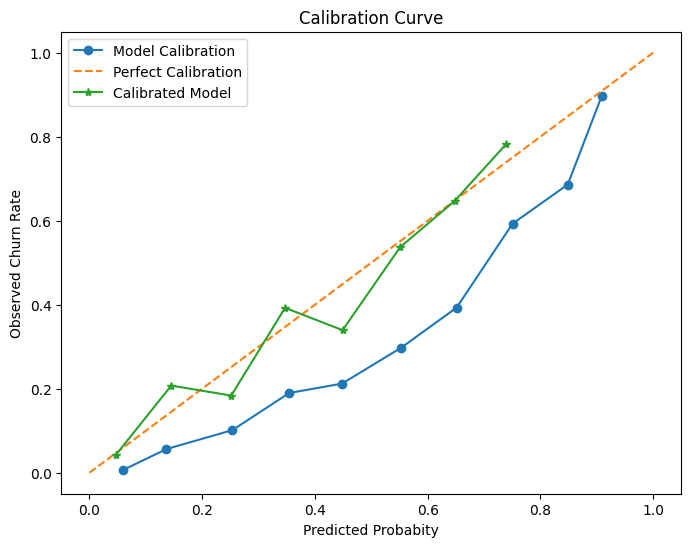

In [39]:
prob_True, prob_pred = calibration_curve(y_test, y_prob, n_bins= 10, strategy="uniform")
prob_true_cal, prob_pred_cal = calibration_curve(y_test, cal_prob, n_bins=10, strategy= "uniform")
plt.figure(figsize=(8,6))
plt.plot(prob_pred, prob_True, marker= "o", label="Model Calibration")
plt.plot([0, 1], [0,1], linestyle='--', label="Perfect Calibration")
plt.plot(prob_pred_cal, prob_true_cal, marker="*", label= "Calibrated Model")
plt.xlabel("Predicted Probabity")
plt.ylabel("Observed Churn Rate")
plt.legend()
plt.title("Calibration Curve")
plt.show()

In [40]:
cal_brier = brier_score_loss(y_test, cal_prob)
print(cal_brier)

0.13573110288305054


In [41]:
y_prob_cal = calibrated_model.predict_proba(x_test)[:, 1]
errordf = x_test.copy()
errordf["y_true"] = y_test.values
errordf["y_prob"] = y_prob_cal
errordf["y_pred"] = (errordf["y_prob"] >= 0.5).astype(int)


false_negative = errordf[(errordf["y_true"]==1)&(errordf["y_pred"]==0)]
false_positive = errordf[(errordf["y_true"]==0)&(errordf["y_pred"]==1)]
true_negative = errordf[(errordf["y_true"]==0)&(errordf["y_pred"]==0)]
true_positive = errordf[(errordf["y_true"]==1)&(errordf["y_pred"]==1)]

print(false_negative["y_prob"].describe())
print("--" * 30)
print(false_positive["y_prob"].describe())
print("--" * 30)
print(true_positive["y_prob"].describe())
print(true_negative["y_prob"].describe())

count    160.000000
mean       0.271506
std        0.143099
min        0.027770
25%        0.141243
50%        0.292900
75%        0.391744
max        0.499536
Name: y_prob, dtype: float64
------------------------------------------------------------
count    114.000000
mean       0.621017
std        0.075654
min        0.503419
25%        0.558340
50%        0.609158
75%        0.685679
max        0.760514
Name: y_prob, dtype: float64
------------------------------------------------------------
count    214.000000
mean       0.656470
std        0.079124
min        0.500260
25%        0.586100
50%        0.658858
75%        0.730115
max        0.787843
Name: y_prob, dtype: float64
count    921.000000
mean       0.131769
std        0.131400
min        0.025718
25%        0.034403
50%        0.067952
75%        0.182477
max        0.499623
Name: y_prob, dtype: float64


Model Interpretability (SHAP Analysis)

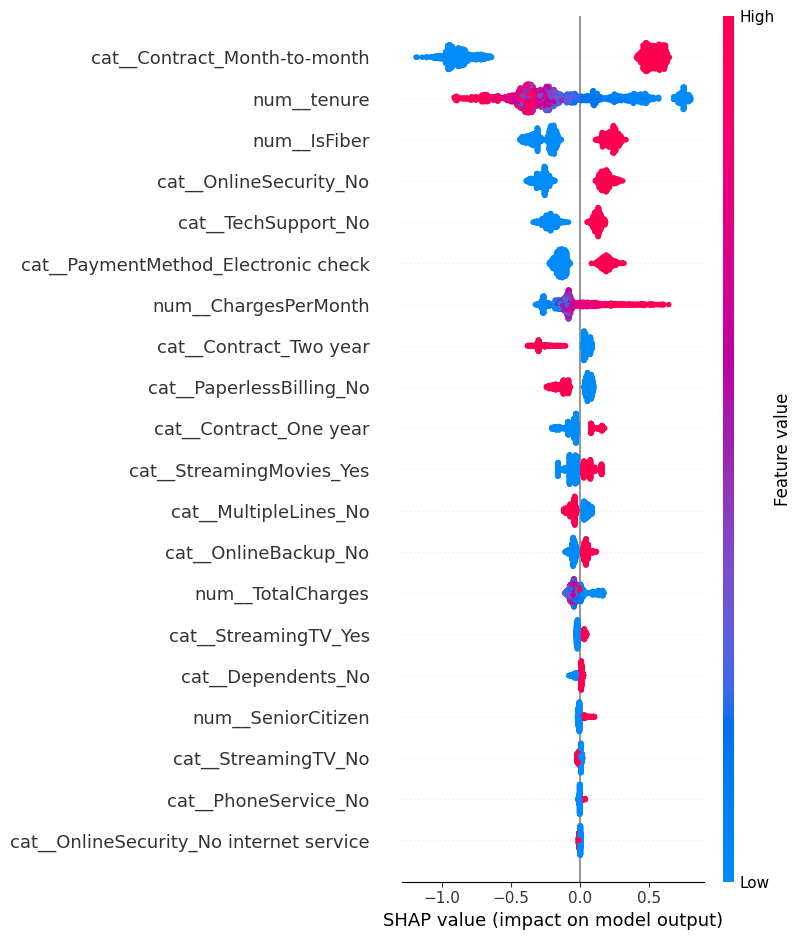

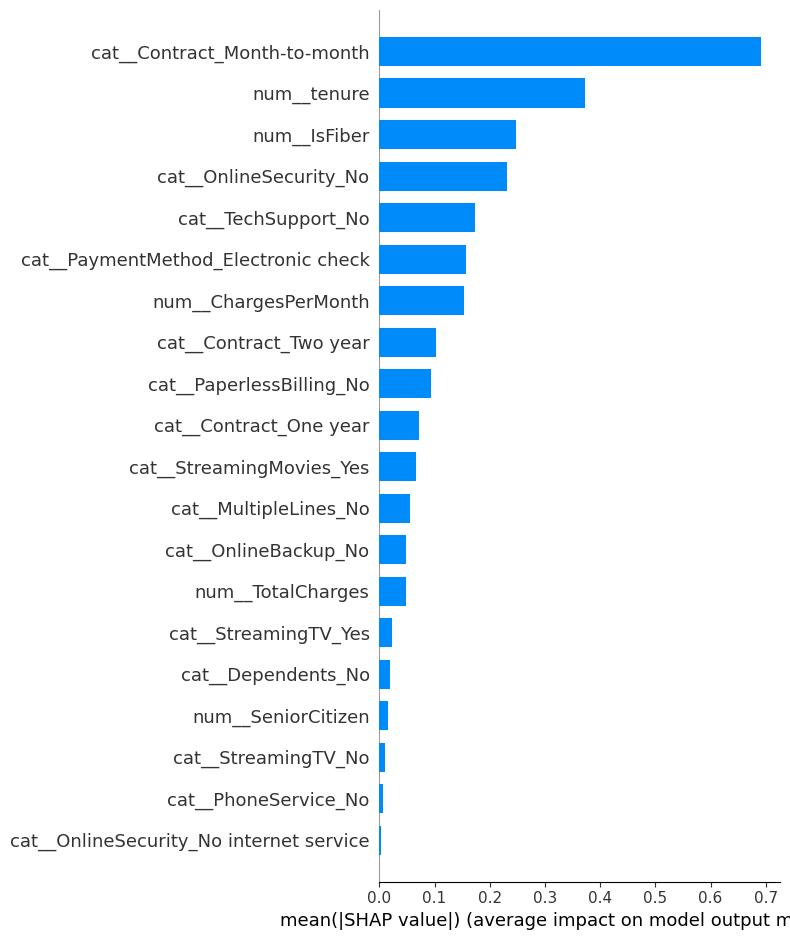

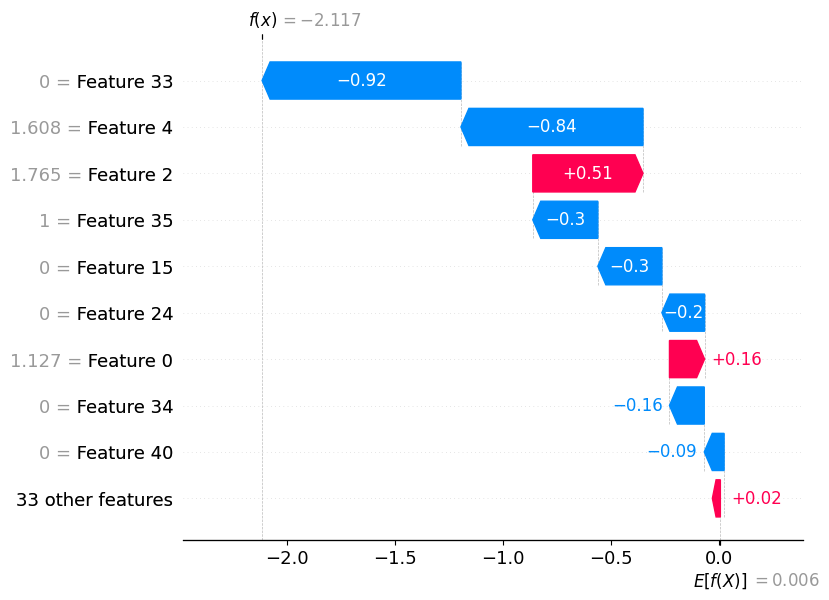

In [24]:

import shap


feature_engineer = best_model.named_steps["new_feature"]
preprocessor = best_model.named_steps["preproces"]
model = best_model.named_steps["model"]


X_test_fe = feature_engineer.transform(x_test)
X_test_processed = preprocessor.transform(X_test_fe)


feature_names = preprocessor.get_feature_names_out()


explainer = shap.TreeExplainer(model)


shap_values = explainer(X_test_processed)


values = shap_values.values


shap.summary_plot(
    values,
    X_test_processed,
    feature_names=feature_names
)


shap.summary_plot(
    values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar"
)


shap.plots.waterfall(shap_values[0])